# 02 - Exploratory Data Analysis

This notebook performs lightweight cleaning, report-focused EDA, and hypothesis testing for the NBA game outcome project.

**Modeling reminder:** the target is whether a team wins a game. Same-game box score stats are useful for understanding patterns, but they are leakage if used directly for prediction. Step 3 should convert useful signals into pre-game, rolling, lagged, or prior-season features.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats as scipy_stats

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', context='notebook')

RAW_DIR = Path('data/raw')
GAME_LOG_DIR = RAW_DIR / 'game_logs'
TEAM_STATS_DIR = RAW_DIR / 'team_stats'
LEAGUE_GAME_FINDER_PATH = RAW_DIR / 'league_game_finder.csv'

# Phase 1: Basic Cleaning

Load the raw data, standardize basic fields, derive helper columns, and validate that the rows are usable for EDA.

In [2]:
game_log_files = sorted(GAME_LOG_DIR.glob('game_logs_*.csv'))
team_stats_files = sorted(TEAM_STATS_DIR.glob('team_stats_*.csv'))

game_logs_all = pd.concat([pd.read_csv(path) for path in game_log_files], ignore_index=True)
team_stats_all = pd.concat([pd.read_csv(path) for path in team_stats_files], ignore_index=True)
league_game_finder = pd.read_csv(LEAGUE_GAME_FINDER_PATH)

dataset_summary = pd.DataFrame(
    [
        {
            'dataset': 'game_logs_all',
            'source': 'data/raw/game_logs/*.csv',
            'files': len(game_log_files),
            'rows': game_logs_all.shape[0],
            'columns': game_logs_all.shape[1],
        },
        {
            'dataset': 'team_stats_all',
            'source': 'data/raw/team_stats/*.csv',
            'files': len(team_stats_files),
            'rows': team_stats_all.shape[0],
            'columns': team_stats_all.shape[1],
        },
        {
            'dataset': 'league_game_finder',
            'source': 'data/raw/league_game_finder.csv',
            'files': 1,
            'rows': league_game_finder.shape[0],
            'columns': league_game_finder.shape[1],
        },
    ]
)

dataset_summary

,dataset,source,files,rows,columns
0,game_logs_all,data/raw/game_logs/*.csv,25,60048,58
1,team_stats_all,data/raw/team_stats/*.csv,25,746,47
2,league_game_finder,data/raw/league_game_finder.csv,1,60048,29


In [3]:
rank_columns = [column for column in game_logs_all.columns if column.endswith('_RANK')]
metadata_columns_to_ignore = ['AVAILABLE_FLAG'] + rank_columns

game_logs_clean = (
    game_logs_all
    .drop(columns=metadata_columns_to_ignore, errors='ignore')
    .assign(
        GAME_DATE=lambda frame: pd.to_datetime(frame['GAME_DATE'], errors='raise'),
        is_win=lambda frame: frame['WL'].map({'W': 1, 'L': 0}).astype('int8'),
        is_home=lambda frame: frame['MATCHUP'].str.contains(' vs. ', regex=False),
        opponent_abbr=lambda frame: frame['MATCHUP'].str.extract(r'(?:vs\.|@)\s+([A-Z]{2,3})', expand=False),
        season_start_year=lambda frame: frame['SEASON_YEAR'].str.slice(0, 4).astype('int16'),
        game_year=lambda frame: frame['GAME_DATE'].dt.year.astype('int16'),
        game_month=lambda frame: frame['GAME_DATE'].dt.month.astype('int8'),
        point_margin=lambda frame: frame['PLUS_MINUS'],
    )
)

season_order_lookup = pd.Series(
    data=range(1, game_logs_clean['SEASON_YEAR'].nunique() + 1),
    index=sorted(game_logs_clean['SEASON_YEAR'].unique()),
)
game_logs_clean = game_logs_clean.assign(
    season_order=lambda frame: frame['SEASON_YEAR'].map(season_order_lookup).astype('int16')
)

team_rank_columns = [column for column in team_stats_all.columns if column.endswith('_RANK')]
team_stats_clean = (
    team_stats_all
    .drop(columns=team_rank_columns, errors='ignore')
    .assign(
        season_start_year=lambda frame: frame['SEASON'].str.slice(0, 4).astype('int16'),
        season_order=lambda frame: frame['SEASON'].map(season_order_lookup).astype('int16'),
    )
)

home_counts_by_game = game_logs_clean.groupby('GAME_ID')['is_home'].sum()
neutral_or_unresolved_game_ids = home_counts_by_game.loc[home_counts_by_game.ne(1)].index
game_logs_clean = game_logs_clean.assign(
    is_neutral_or_unresolved=lambda frame: frame['GAME_ID'].isin(neutral_or_unresolved_game_ids)
)

assert game_logs_all.shape[0] == 60048
assert team_stats_all.shape[0] == 746
assert set(game_logs_clean['WL'].unique()) == {'W', 'L'}
assert not game_logs_clean.duplicated(['GAME_ID', 'TEAM_ID']).any()
assert game_logs_clean.groupby('GAME_ID').size().eq(2).all()

unexpected_game_nulls = game_logs_clean.isna().sum().loc[lambda counts: counts.gt(0)]
unexpected_team_nulls = team_stats_clean.isna().sum().loc[lambda counts: counts.gt(0)]
assert unexpected_game_nulls.empty
assert unexpected_team_nulls.empty

print('Cleaning checks passed.')
print(f'Ignored game-log metadata columns: {len(metadata_columns_to_ignore)}')
print(f'Neutral or unresolved home/away games: {len(neutral_or_unresolved_game_ids)}')

Cleaning checks passed.
Ignored game-log metadata columns: 27
Neutral or unresolved home/away games: 5


In [4]:
raw_missing_summary = (
    pd.concat(
        [
            game_logs_all.isna().sum().rename('missing_values').to_frame().assign(dataset='game_logs_all'),
            team_stats_all.isna().sum().rename('missing_values').to_frame().assign(dataset='team_stats_all'),
            league_game_finder.isna().sum().rename('missing_values').to_frame().assign(dataset='league_game_finder'),
        ]
    )
    .reset_index(names='column')
    .query('missing_values > 0')
    .sort_values(['dataset', 'missing_values'], ascending=[True, False])
)

validation_summary = pd.DataFrame(
    [
        {'check': 'Duplicate GAME_ID + TEAM_ID rows', 'value': int(game_logs_clean.duplicated(['GAME_ID', 'TEAM_ID']).sum())},
        {'check': 'Games with exactly two team rows', 'value': int(game_logs_clean.groupby('GAME_ID').size().eq(2).sum())},
        {'check': 'Total unique games', 'value': int(game_logs_clean['GAME_ID'].nunique())},
        {'check': 'Neutral or unresolved home/away games', 'value': int(len(neutral_or_unresolved_game_ids))},
        {'check': 'Unexpected nulls after cleaning', 'value': int(unexpected_game_nulls.sum() + unexpected_team_nulls.sum())},
    ]
)

display(raw_missing_summary)
display(validation_summary)

,column,missing_values,dataset
56,AVAILABLE_FLAG,28726,game_logs_all
123,FT_PCT,1,league_game_finder


,check,value
0,Duplicate GAME_ID + TEAM_ID rows,0
1,Games with exactly two team rows,30024
2,Total unique games,30024
3,Neutral or unresolved home/away games,5
4,Unexpected nulls after cleaning,0


### Cleaning Notes

- `game_logs_clean` is the main team-game DataFrame for EDA.
- `team_stats_clean` gives season-level team context.
- `league_game_finder` is kept as a validation source because it overlaps with game logs but has a small amount of missingness and fewer useful columns.
- Rank columns and `AVAILABLE_FLAG` are ignored for EDA because they are endpoint metadata rather than interpretable modeling inputs.

# Phase 2: EDA

This section builds a report-friendly picture of the data: coverage, target balance, home advantage, league trends, winner/loser differences, and season-level team strength.

In [5]:
non_neutral_games = game_logs_clean.loc[~game_logs_clean['is_neutral_or_unresolved']].copy()
home_rows = non_neutral_games.loc[non_neutral_games['is_home']].copy()

season_summary = (
    game_logs_clean
    .groupby('SEASON_YEAR')
    .agg(
        rows=('GAME_ID', 'size'),
        games=('GAME_ID', 'nunique'),
        teams=('TEAM_ID', 'nunique'),
        avg_points=('PTS', 'mean'),
        avg_fg_pct=('FG_PCT', 'mean'),
        avg_fg3a=('FG3A', 'mean'),
        avg_fg3_pct=('FG3_PCT', 'mean'),
        avg_turnovers=('TOV', 'mean'),
    )
    .reset_index()
)

season_home_summary = (
    home_rows
    .groupby('SEASON_YEAR')
    .agg(home_games=('GAME_ID', 'nunique'), home_wins=('is_win', 'sum'))
    .assign(home_win_rate=lambda frame: frame['home_wins'] / frame['home_games'])
    .reset_index()
)

season_team_summary = (
    team_stats_clean
    .groupby('SEASON')
    .agg(
        avg_pace=('PACE', 'mean'),
        avg_off_rating=('OFF_RATING', 'mean'),
        avg_def_rating=('DEF_RATING', 'mean'),
        avg_net_rating=('NET_RATING', 'mean'),
        avg_ts_pct=('TS_PCT', 'mean'),
    )
    .reset_index()
    .rename(columns={'SEASON': 'SEASON_YEAR'})
)

season_summary = (
    season_summary
    .merge(season_home_summary, on='SEASON_YEAR', how='left')
    .merge(season_team_summary, on='SEASON_YEAR', how='left')
)

target_balance = (
    game_logs_clean['WL']
    .value_counts()
    .rename_axis('WL')
    .reset_index(name='rows')
    .assign(share=lambda frame: frame['rows'] / frame['rows'].sum())
)

display(season_summary.head())
display(season_summary.tail())
display(target_balance)

,SEASON_YEAR,rows,games,teams,avg_points,avg_fg_pct,avg_fg3a,avg_fg3_pct,avg_turnovers,home_games,home_wins,home_win_rate,avg_pace,avg_off_rating,avg_def_rating,avg_net_rating,avg_ts_pct
0,2000-01,2378,1189,29,94.8103,0.4442,13.7077,0.3486,15.0484,1189,711,0.5980,92.5841,101.5552,101.5448,0.0103,0.5180
1,2001-02,2378,1189,29,95.4765,0.4462,14.7494,0.3516,14.4605,1189,703,0.5913,91.9572,103.0931,103.1103,-0.0138,0.5203
2,2002-03,2378,1189,29,95.0807,0.4431,14.6817,0.3435,14.9163,1189,747,0.6283,92.3003,102.1621,102.1586,-0.0069,0.5192
3,2003-04,2378,1189,29,93.3978,0.4394,14.9256,0.3430,14.9752,1189,730,0.6140,91.4500,101.3931,101.3724,0.0241,0.5161
4,2004-05,2460,1230,30,97.1988,0.4486,15.7512,0.3516,14.5028,1230,744,0.6049,92.2743,104.5067,104.5100,-0.0067,0.5294


,SEASON_YEAR,rows,games,teams,avg_points,avg_fg_pct,avg_fg3a,avg_fg3_pct,avg_turnovers,home_games,home_wins,home_win_rate,avg_pace,avg_off_rating,avg_def_rating,avg_net_rating,avg_ts_pct
20,2020-21,2160,1080,30,112.0912,0.4669,34.6398,0.3654,13.8356,1080,587,0.5435,99.7500,111.7133,111.6967,0.0133,0.5718
21,2021-22,2460,1230,30,110.6159,0.4620,35.1768,0.3531,13.7626,1230,669,0.5439,98.7543,111.3833,111.3600,0.0133,0.5662
22,2022-23,2460,1230,30,114.6858,0.4766,34.2130,0.3593,14.0955,1230,714,0.5805,99.7917,114.0767,114.0700,0.0200,0.5815
23,2023-24,2460,1230,30,114.2114,0.4752,35.1037,0.3649,13.6049,1230,668,0.5431,99.1497,114.5467,114.5167,0.0367,0.5800
24,2024-25,2460,1230,30,113.8252,0.4682,37.5829,0.3599,14.2984,1225,667,0.5445,99.5797,113.6800,113.6833,0.0000,0.5762


,WL,rows,share
0,W,30024,0.5000
1,L,30024,0.5000


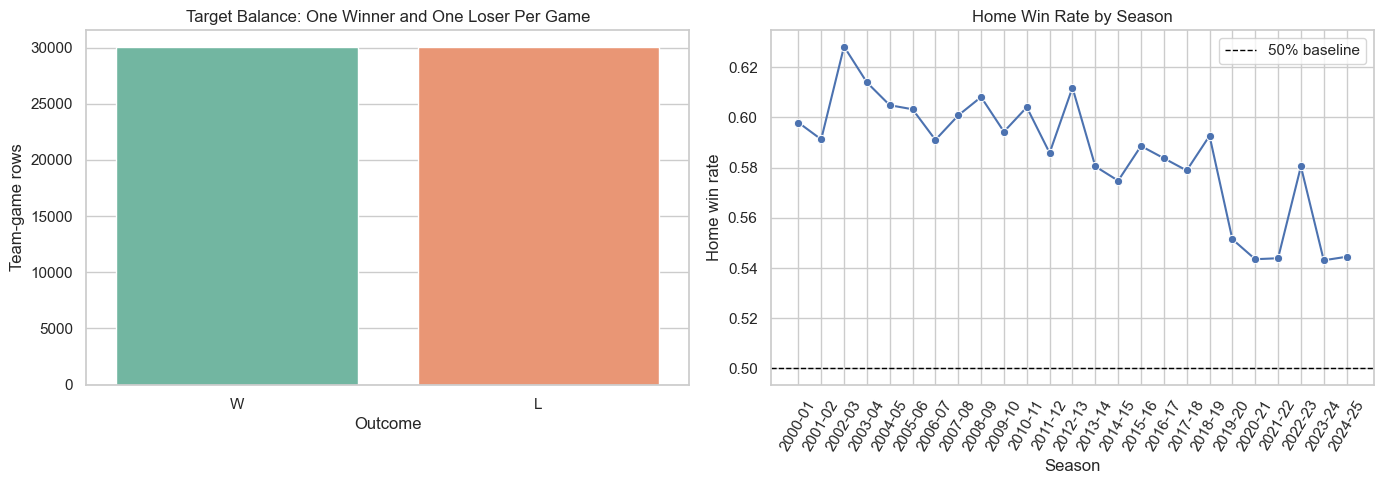

EDA note: the target is balanced by construction because each game appears once for each team.
Home court is not balanced against 50%, so it is a strong candidate feature for Step 3.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=target_balance, x='WL', y='rows', hue='WL', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Target Balance: One Winner and One Loser Per Game')
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Team-game rows')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='home_win_rate', marker='o', ax=axes[1])
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=1, label='50% baseline')
axes[1].set_title('Home Win Rate by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Home win rate')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend()

plt.tight_layout()
plt.show()

print('EDA note: the target is balanced by construction because each game appears once for each team.')
print('Home court is not balanced against 50%, so it is a strong candidate feature for Step 3.')

### Basketball interpretation: home court

Home court is a model-safe feature because it is known before tip-off. Basketball-wise, it can capture travel fatigue, crowd environment, routine, and comfort with the arena. The EDA says to include `is_home`, but not to overstate it: the home edge changes by era and is weaker in recent seasons than in the early 2000s.

**Model build-out:** keep `is_home`, keep `is_neutral_or_unresolved`, and add schedule features such as `days_rest`, `is_back_to_back`, and possibly road-trip length. These features are safer than same-game scoring stats because they are available before the game starts.

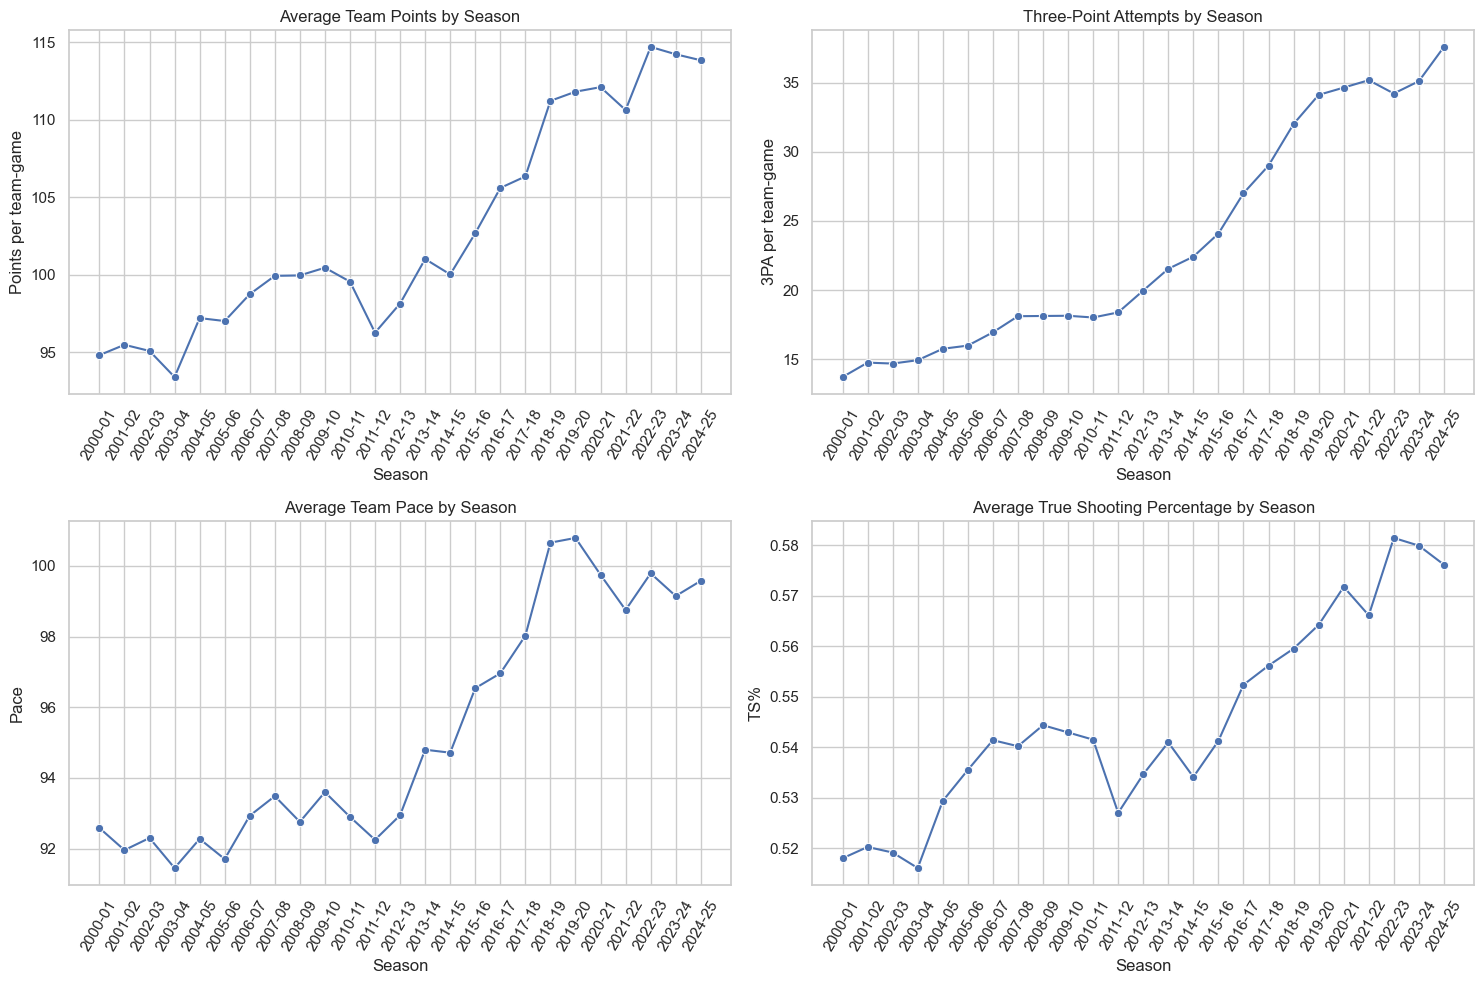

EDA note: league context changes over time, so Step 4 should use time-aware validation rather than random k-fold splits.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_points', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Average Team Points by Season')
axes[0, 0].set_ylabel('Points per team-game')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_fg3a', marker='o', ax=axes[0, 1])
axes[0, 1].set_title('Three-Point Attempts by Season')
axes[0, 1].set_ylabel('3PA per team-game')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_pace', marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Average Team Pace by Season')
axes[1, 0].set_ylabel('Pace')

sns.lineplot(data=season_summary, x='SEASON_YEAR', y='avg_ts_pct', marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Average True Shooting Percentage by Season')
axes[1, 1].set_ylabel('TS%')

for axis in axes.flatten():
    axis.set_xlabel('Season')
    axis.tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

print('EDA note: league context changes over time, so Step 4 should use time-aware validation rather than random k-fold splits.')

### Basketball interpretation: era effects

Raw scoring is hard to compare across eras. A 110-point game meant something different in 2003 than it does in 2024 because pace, three-point volume, spacing, and shooting efficiency have all changed. This is why raw points per game should not be treated as a universal strength measure.

**Model build-out:** prefer rolling and relative features: team rolling points above league average, rolling offensive efficiency, rolling three-point attempt rate, and season controls. Use time-aware validation so the model learns from earlier seasons and tests on later ones.

WL,Loser average,Winner average,winner_minus_loser
PLUS_MINUS,-11.1904,11.1904,22.3809
PTS,97.2053,108.3958,11.1904
REB,41.0946,44.5330,3.4384
AST,21.0387,24.3539,3.3152
BLK,4.4721,5.3098,0.8377
STL,7.2023,8.0029,0.8006
FG3_PCT,0.3217,0.3873,0.0657
FG_PCT,0.4322,0.4822,0.0500
FT_PCT,0.7521,0.7729,0.0208
TOV,14.7946,13.9215,-0.8731


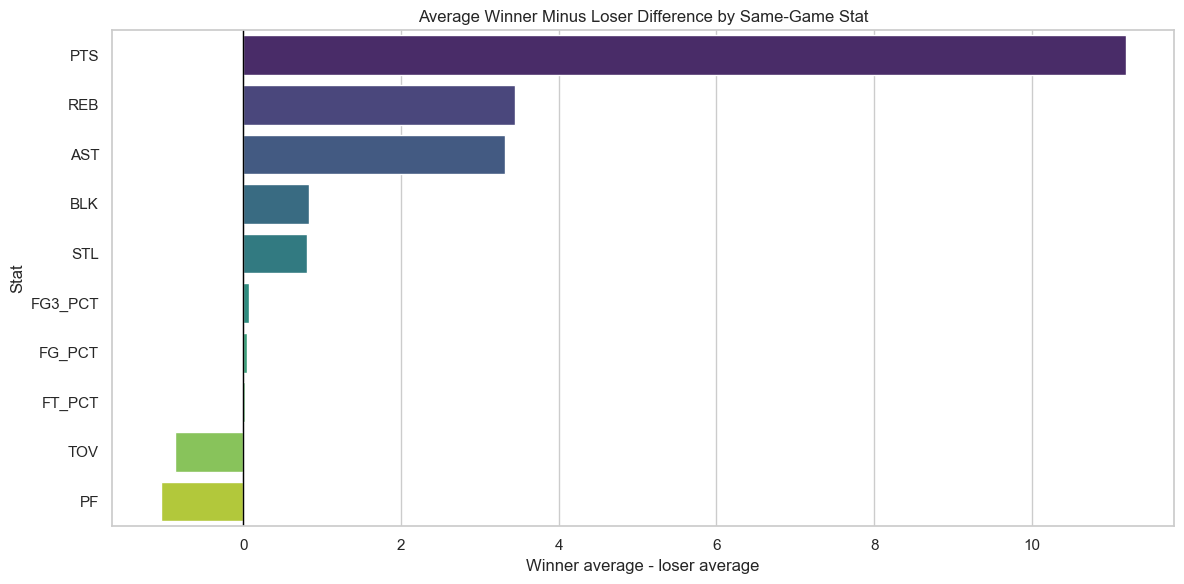

Leakage note: these same-game differences are descriptive only. Step 3 should create rolling or lagged versions before modeling.


In [8]:
winner_loser_stats = ['PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'PLUS_MINUS']

winner_loser_summary = (
    game_logs_clean
    .groupby('WL')[winner_loser_stats]
    .mean()
    .rename(index={'W': 'Winner average', 'L': 'Loser average'})
    .transpose()
    .assign(winner_minus_loser=lambda frame: frame['Winner average'] - frame['Loser average'])
    .sort_values('winner_minus_loser', ascending=False)
)

display(winner_loser_summary)

plot_diffs = (
    winner_loser_summary
    .drop(index=['PLUS_MINUS'])
    .reset_index(names='stat')
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_diffs, x='winner_minus_loser', y='stat', hue='stat', palette='viridis', legend=False)
plt.axvline(0, color='black', linewidth=1)
plt.title('Average Winner Minus Loser Difference by Same-Game Stat')
plt.xlabel('Winner average - loser average')
plt.ylabel('Stat')
plt.tight_layout()
plt.show()

print('Leakage note: these same-game differences are descriptive only. Step 3 should create rolling or lagged versions before modeling.')

### Basketball interpretation: box-score differences and leakage

The winner-vs-loser table makes `PTS`, `PLUS_MINUS`, shooting percentages, assists, rebounds, steals, blocks, turnovers, and fouls look important. That is true descriptively, but many of these are **not usable as current-game model features**. `PLUS_MINUS` is especially dangerous because it is literally the scoring margin after the game. Current-game `PTS` also answers the prediction problem after the fact.

Basketball logic still makes these useful for feature design. The goal is not to tell the model who scored more tonight; it is to tell the model which team entered the game with signs of better offense, defense, ball security, and possession control.

**Model build-out:** convert these into pre-game features by sorting each team by `GAME_DATE` and using shifted rolling windows. Examples: rolling point differential, rolling points scored, rolling points allowed, rolling FG%, rolling 3P%, rolling assist-to-turnover ratio, rolling turnover rate, rolling defensive rebounds, rolling steals, and rolling blocks. Every rolling value must be shifted so the current game is excluded.

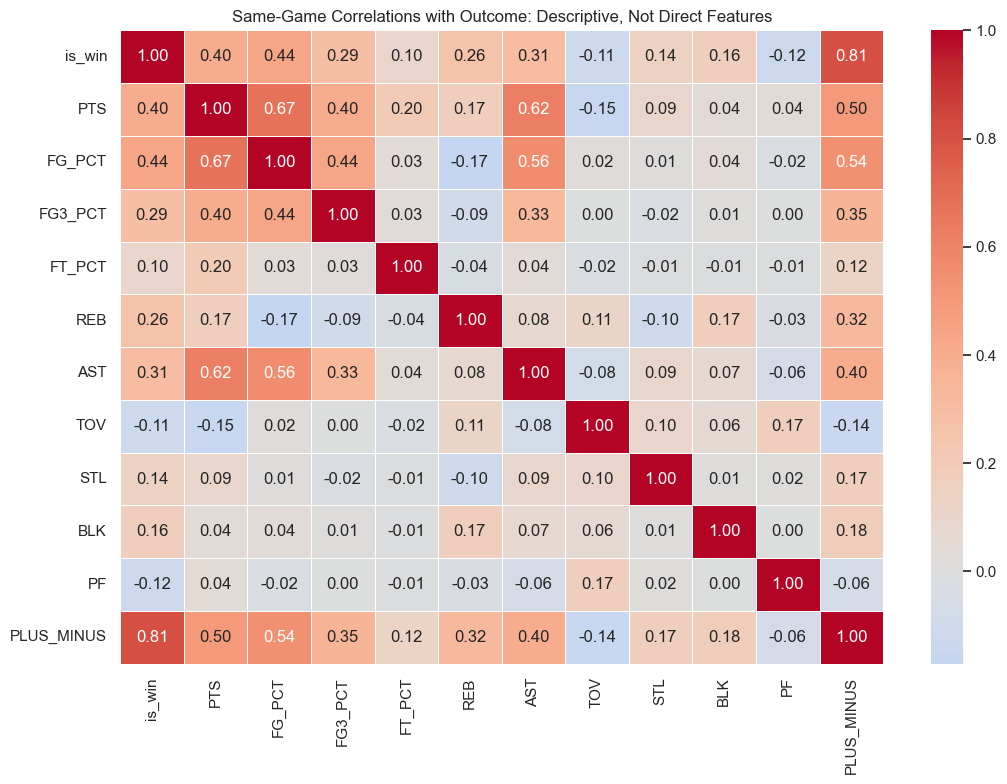

,corr_with_is_win
PLUS_MINUS,0.8071
FG_PCT,0.4437
PTS,0.4022
AST,0.3097
FG3_PCT,0.2946
REB,0.2603
BLK,0.1634
STL,0.1373
PF,-0.1176
TOV,-0.1108


In [9]:
same_game_corr_columns = ['is_win', 'PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF', 'PLUS_MINUS']
same_game_corr = game_logs_clean[same_game_corr_columns].corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(same_game_corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Same-Game Correlations with Outcome: Descriptive, Not Direct Features')
plt.tight_layout()
plt.show()

same_game_corr['is_win'].drop('is_win').sort_values(key=lambda values: values.abs(), ascending=False).to_frame('corr_with_is_win')

### Basketball interpretation: correlations are a feature-design map, not a feature list

High correlations with `is_win` should be read as basketball clues, not permission to use those columns directly. `PLUS_MINUS` and `PTS` are outcomes. Current-game shooting percentage tells us how well a team shot in the game we are trying to predict. Current-game assists, rebounds, steals, and blocks are also post-tip-off events.

**Model build-out:** use the correlated categories to create lagged predictors: recent scoring margin for team quality, recent shooting efficiency for offensive form, recent defensive rebounds for ending possessions, recent turnovers for ball security, and recent steals/blocks for defensive disruption. Then create opponent-adjusted versions, such as team rolling offense minus opponent rolling defense.

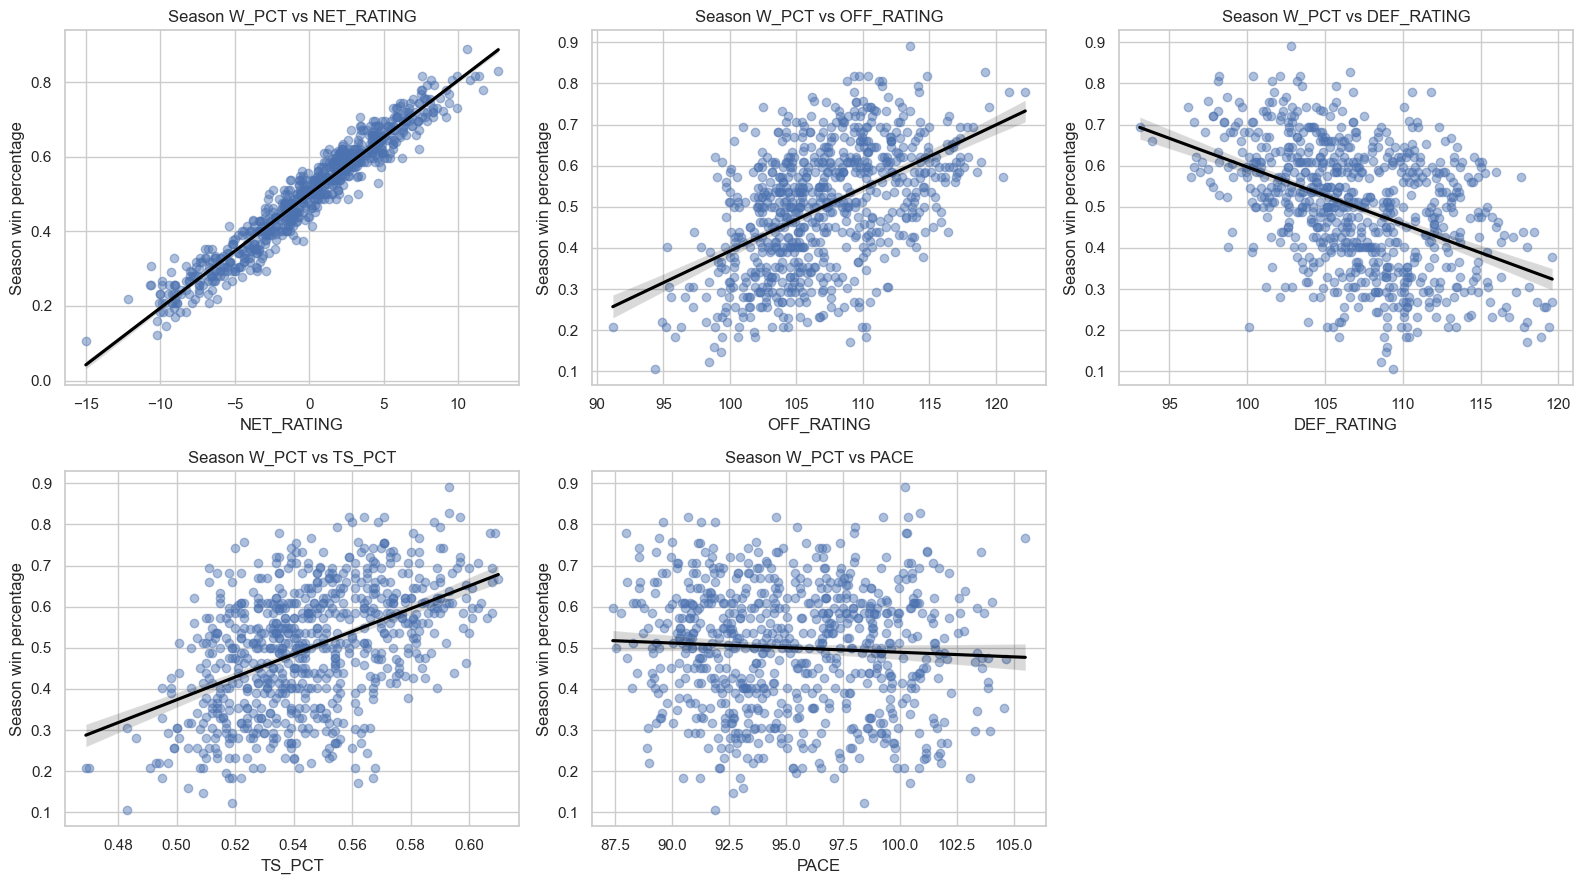

EDA note: season-level team quality metrics are available before future games and can become priors or lagged features.


In [10]:
team_strength_metrics = ['NET_RATING', 'OFF_RATING', 'DEF_RATING', 'TS_PCT', 'PACE']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_list = list(axes.flatten())

for metric, axis in zip(team_strength_metrics, axes_list):
    sns.regplot(data=team_stats_clean, x=metric, y='W_PCT', scatter_kws={'alpha': 0.45}, line_kws={'color': 'black'}, ax=axis)
    axis.set_title(f'Season W_PCT vs {metric}')
    axis.set_xlabel(metric)
    axis.set_ylabel('Season win percentage')

axes_list[-1].axis('off')
plt.tight_layout()
plt.show()

print('EDA note: season-level team quality metrics are available before future games and can become priors or lagged features.')

### Basketball interpretation: team quality metrics

Season-level `NET_RATING`, `OFF_RATING`, `DEF_RATING`, and `TS_PCT` line up with basketball intuition: good teams win because they create efficient offense, prevent efficient offense, and win the possession math over many games. `PACE` alone is less meaningful because playing fast is not automatically playing well.

**Model build-out:** do not use final-season values for games inside that same season. Use prior-season values before the season starts, then update with shifted to-date or rolling values once enough games have been played. Prioritize rolling net rating, rolling offensive rating, rolling defensive rating, and rolling true shooting over raw pace.

# Phase 3: Hypothesis Testing

These tests support the report narrative and help decide which feature families are worth engineering. Statistical significance is not the same as modeling usefulness, so the final section translates results into Step 3 feature ideas.

In [11]:
def p_value_label(p_value):
    if p_value < 0.001:
        return 'p < 0.001'
    if p_value < 0.01:
        return 'p < 0.01'
    if p_value < 0.05:
        return 'p < 0.05'
    return 'not significant at 0.05'


def practical_size_label(value, small=0.10, medium=0.30, large=0.50):
    absolute_value = abs(value)
    if absolute_value >= large:
        return 'large'
    if absolute_value >= medium:
        return 'medium'
    if absolute_value >= small:
        return 'small'
    return 'very small'


home_wins = int(home_rows['is_win'].sum())
home_games = int(home_rows.shape[0])
home_win_rate = home_wins / home_games
home_advantage_test = scipy_stats.binomtest(home_wins, n=home_games, p=0.5, alternative='two-sided')
home_advantage_ci = home_advantage_test.proportion_ci(confidence_level=0.95, method='wilson')

home_advantage_result = pd.DataFrame(
    [
        {
            'hypothesis': 'Home teams win more than a 50% baseline',
            'sample_size': home_games,
            'estimate': home_win_rate,
            'ci_95_low': home_advantage_ci.low,
            'ci_95_high': home_advantage_ci.high,
            'p_value': home_advantage_test.pvalue,
            'interpretation': f'Home teams won {home_win_rate:.1%} of non-neutral games; {p_value_label(home_advantage_test.pvalue)}.',
        }
    ]
)

home_advantage_result

,hypothesis,sample_size,estimate,ci_95_low,ci_95_high,p_value,interpretation
0,Home teams win more than a 50% baseline,30019,0.5860,0.5804,0.5915,0.0000,Home teams won 58.6% of non-neutral games; p <...


In [12]:
paired_test_stats = ['PTS', 'FG_PCT', 'FG3_PCT', 'REB', 'AST', 'TOV', 'STL', 'BLK', 'PF']
paired_test_rows = []

for stat_name in paired_test_stats:
    stat_by_outcome = game_logs_clean.pivot(index='GAME_ID', columns='WL', values=stat_name).dropna()
    winner_minus_loser = stat_by_outcome['W'] - stat_by_outcome['L']
    test_result = scipy_stats.ttest_1samp(winner_minus_loser, popmean=0)
    standard_error = winner_minus_loser.sem()
    ci_low, ci_high = scipy_stats.t.interval(
        confidence=0.95,
        df=winner_minus_loser.shape[0] - 1,
        loc=winner_minus_loser.mean(),
        scale=standard_error,
    )
    effect_size = winner_minus_loser.mean() / winner_minus_loser.std(ddof=1)
    paired_test_rows.append(
        {
            'stat': stat_name,
            'games': int(winner_minus_loser.shape[0]),
            'mean_winner_minus_loser': winner_minus_loser.mean(),
            'ci_95_low': ci_low,
            'ci_95_high': ci_high,
            'p_value': test_result.pvalue,
            'effect_size_d': effect_size,
            'effect_size_label': practical_size_label(effect_size),
            'interpretation': f'Winners differ on {stat_name}; {p_value_label(test_result.pvalue)}. Convert to rolling/lagged feature before modeling.',
        }
    )

paired_stat_tests = pd.DataFrame(paired_test_rows).sort_values('mean_winner_minus_loser', ascending=False)
paired_stat_tests

,stat,games,mean_winner_minus_loser,ci_95_low,ci_95_high,p_value,effect_size_d,effect_size_label,interpretation
0,PTS,30024,11.1904,11.0978,11.2831,0.0000,1.3669,large,Winners differ on PTS; p < 0.001. Convert to r...
3,REB,30024,3.4384,3.3429,3.5340,0.0000,0.4070,medium,Winners differ on REB; p < 0.001. Convert to r...
4,AST,30024,3.3152,3.2463,3.3841,0.0000,0.5445,large,Winners differ on AST; p < 0.001. Convert to r...
7,BLK,30024,0.8377,0.7985,0.8768,0.0000,0.2419,small,Winners differ on BLK; p < 0.001. Convert to r...
6,STL,30024,0.8006,0.7569,0.8444,0.0000,0.2070,small,Winners differ on STL; p < 0.001. Convert to r...
2,FG3_PCT,30024,0.0657,0.0640,0.0673,0.0000,0.4564,medium,Winners differ on FG3_PCT; p < 0.001. Convert ...
1,FG_PCT,30024,0.0500,0.0494,0.0507,0.0000,0.8315,large,Winners differ on FG_PCT; p < 0.001. Convert t...
5,TOV,30024,-0.8731,-0.9297,-0.8165,0.0000,-0.1745,small,Winners differ on TOV; p < 0.001. Convert to r...
8,PF,30024,-1.0516,-1.1089,-0.9943,0.0000,-0.2075,small,Winners differ on PF; p < 0.001. Convert to ro...


In [13]:
team_strength_test_rows = []

for metric in team_strength_metrics:
    valid_rows = team_stats_clean[['W_PCT', metric]].dropna()
    pearson_r, pearson_p = scipy_stats.pearsonr(valid_rows[metric], valid_rows['W_PCT'])
    spearman_r, spearman_p = scipy_stats.spearmanr(valid_rows[metric], valid_rows['W_PCT'])
    team_strength_test_rows.append(
        {
            'metric': metric,
            'teams_seasons': int(valid_rows.shape[0]),
            'pearson_r': pearson_r,
            'pearson_p_value': pearson_p,
            'spearman_r': spearman_r,
            'spearman_p_value': spearman_p,
            'interpretation': f'{metric} has a {practical_size_label(pearson_r)} linear association with W_PCT; {p_value_label(pearson_p)}.',
        }
    )

team_strength_tests = pd.DataFrame(team_strength_test_rows).sort_values('pearson_r', key=lambda values: values.abs(), ascending=False)
team_strength_tests

,metric,teams_seasons,pearson_r,pearson_p_value,spearman_r,spearman_p_value,interpretation
0,NET_RATING,746,0.9676,0.0000,0.9702,0.0000,NET_RATING has a large linear association with...
1,OFF_RATING,746,0.5068,0.0000,0.4974,0.0000,OFF_RATING has a large linear association with...
3,TS_PCT,746,0.4769,0.0000,0.4570,0.0000,TS_PCT has a medium linear association with W_...
2,DEF_RATING,746,-0.4404,0.0000,-0.4316,0.0000,DEF_RATING has a medium linear association wit...
4,PACE,746,-0.0583,0.1119,-0.0577,0.1152,PACE has a very small linear association with ...


In [14]:
trend_test_metrics = {
    'avg_points': 'Average team scoring',
    'avg_fg3a': 'Three-point attempt volume',
    'avg_pace': 'Pace',
    'home_win_rate': 'Home win rate',
}

trend_test_rows = []
trend_frame = season_summary.assign(season_start_year=lambda frame: frame['SEASON_YEAR'].str.slice(0, 4).astype('int16'))

for metric, label in trend_test_metrics.items():
    valid_rows = trend_frame[['season_start_year', metric]].dropna()
    pearson_r, pearson_p = scipy_stats.pearsonr(valid_rows['season_start_year'], valid_rows[metric])
    linear_fit = scipy_stats.linregress(valid_rows['season_start_year'], valid_rows[metric])
    trend_test_rows.append(
        {
            'metric': metric,
            'label': label,
            'seasons': int(valid_rows.shape[0]),
            'slope_per_season': linear_fit.slope,
            'pearson_r': pearson_r,
            'p_value': pearson_p,
            'interpretation': f'{label} trend is {p_value_label(pearson_p)} with slope {linear_fit.slope:.4f} per season.',
        }
    )

league_trend_tests = pd.DataFrame(trend_test_rows).sort_values('p_value')
league_trend_tests

,metric,label,seasons,slope_per_season,pearson_r,p_value,interpretation
1,avg_fg3a,Three-point attempt volume,25,1.0586,0.9603,0.0000,Three-point attempt volume trend is p < 0.001 ...
0,avg_points,Average team scoring,25,0.8844,0.9333,0.0000,Average team scoring trend is p < 0.001 with s...
2,avg_pace,Pace,25,0.4062,0.9089,0.0000,Pace trend is p < 0.001 with slope 0.4062 per ...
3,home_win_rate,Home win rate,25,-0.0026,-0.8050,0.0000,Home win rate trend is p < 0.001 with slope -0...


In [15]:
hypothesis_test_summary = pd.concat(
    [
        home_advantage_result.assign(test_family='Home-court advantage').rename(columns={'hypothesis': 'test'}),
        paired_stat_tests.assign(test_family='Winner vs loser same-game differences').rename(columns={'stat': 'test'}),
        team_strength_tests.assign(test_family='Team strength vs season W_PCT').rename(columns={'metric': 'test'}),
        league_trend_tests.assign(test_family='League trend over time').rename(columns={'label': 'test'}),
    ],
    ignore_index=True,
    sort=False,
)

hypothesis_test_summary[['test_family', 'test', 'p_value', 'interpretation']].fillna('see family-specific p-value column')

,test_family,test,p_value,interpretation
0,Home-court advantage,Home teams win more than a 50% baseline,0.0000,Home teams won 58.6% of non-neutral games; p <...
1,Winner vs loser same-game differences,PTS,0.0000,Winners differ on PTS; p < 0.001. Convert to r...
2,Winner vs loser same-game differences,REB,0.0000,Winners differ on REB; p < 0.001. Convert to r...
3,Winner vs loser same-game differences,AST,0.0000,Winners differ on AST; p < 0.001. Convert to r...
4,Winner vs loser same-game differences,BLK,0.0000,Winners differ on BLK; p < 0.001. Convert to r...
5,Winner vs loser same-game differences,STL,0.0000,Winners differ on STL; p < 0.001. Convert to r...
6,Winner vs loser same-game differences,FG3_PCT,0.0000,Winners differ on FG3_PCT; p < 0.001. Convert ...
7,Winner vs loser same-game differences,FG_PCT,0.0000,Winners differ on FG_PCT; p < 0.001. Convert t...
8,Winner vs loser same-game differences,TOV,0.0000,Winners differ on TOV; p < 0.001. Convert to r...
9,Winner vs loser same-game differences,PF,0.0000,Winners differ on PF; p < 0.001. Convert to ro...


# Phase 4: Step 3 Takeaways

This section translates the cleaning, EDA, and hypothesis testing into feature-engineering guidance for `03_cleaning_features.ipynb`.

In [16]:
feature_recommendations = pd.DataFrame(
    [
        {
            'feature_family': 'Home / away indicator',
            'step_3_action': 'Create is_home and handle neutral/unresolved games explicitly.',
            'why_it_matters': 'Home win rate is meaningfully above 50% in non-neutral games.',
            'leakage_status': 'Safe before tip-off',
        },
        {
            'feature_family': 'Rest and schedule context',
            'step_3_action': 'Use GAME_DATE by TEAM_ID to compute days since last game and back-to-back flags.',
            'why_it_matters': 'Schedule context is known before tip-off and may explain performance swings.',
            'leakage_status': 'Safe before tip-off',
        },
        {
            'feature_family': 'Rolling team form',
            'step_3_action': 'Create lagged rolling means for win rate, points, margin, FG%, 3PA, rebounds, assists, turnovers, steals, and blocks.',
            'why_it_matters': 'Winner/loser tests show strong same-game differences; rolling pre-game versions can capture form without leakage.',
            'leakage_status': 'Safe only when shifted before current game',
        },
        {
            'feature_family': 'Avoid direct result stats',
            'step_3_action': 'Do not use current-game PLUS_MINUS, PTS, FG%, 3P%, rebounds, assists, turnovers, steals, or blocks directly.',
            'why_it_matters': 'These are post-game box-score outcomes; they identify why the game was won but are not known before tip-off.',
            'leakage_status': 'Leaky if used directly',
        },
        {
            'feature_family': 'Opponent strength',
            'step_3_action': 'Join opponent rolling form and prior-season/team-season quality before each game.',
            'why_it_matters': 'The prediction problem depends on both team quality and opponent quality.',
            'leakage_status': 'Safe only when shifted before current game',
        },
        {
            'feature_family': 'Season-level advanced priors',
            'step_3_action': 'Use prior or to-date OFF_RATING, DEF_RATING, NET_RATING, TS_PCT, and PACE rather than final-season values for current-season games.',
            'why_it_matters': 'Team strength tests show these metrics are associated with season win percentage.',
            'leakage_status': 'Avoid final-season values for games inside that same season',
        },
        {
            'feature_family': 'Era / season controls',
            'step_3_action': 'Include season or season_start_year features, and use time-aware train/test splits.',
            'why_it_matters': 'League scoring, three-point volume, and pace shift materially over time.',
            'leakage_status': 'Safe before tip-off',
        },
    ]
)

feature_recommendations

,feature_family,step_3_action,why_it_matters,leakage_status
0,Home / away indicator,Create is_home and handle neutral/unresolved g...,Home win rate is meaningfully above 50% in non...,Safe before tip-off
1,Rest and schedule context,Use GAME_DATE by TEAM_ID to compute days since...,Schedule context is known before tip-off and m...,Safe before tip-off
2,Rolling team form,"Create lagged rolling means for win rate, poin...",Winner/loser tests show strong same-game diffe...,Safe only when shifted before current game
3,Avoid direct result stats,"Do not use current-game PLUS_MINUS, PTS, FG%, ...",These are post-game box-score outcomes; they i...,Leaky if used directly
4,Opponent strength,Join opponent rolling form and prior-season/te...,The prediction problem depends on both team qu...,Safe only when shifted before current game
5,Season-level advanced priors,"Use prior or to-date OFF_RATING, DEF_RATING, N...",Team strength tests show these metrics are ass...,Avoid final-season values for games inside tha...
6,Era / season controls,"Include season or season_start_year features, ...","League scoring, three-point volume, and pace s...",Safe before tip-off


## Final Takeaways for Step 3

1. The raw game logs are clean enough to use as the main feature-engineering base after dropping endpoint metadata columns like ranks and `AVAILABLE_FLAG`.
2. The modeling row should stay at one team per game, with `GAME_ID` retaining the link to the opposing row.
3. Home court should be included as a pre-game feature, while neutral or unresolved games should be flagged rather than forced into home/away logic.
4. Do **not** use current-game `PLUS_MINUS`, `PTS`, shooting percentages, rebounds, assists, turnovers, steals, or blocks directly. They describe why a team won after the game happened, so they leak the target.
5. Use those same basketball ideas as a build map for Step 3: shifted rolling point differential, rolling points scored and allowed, rolling shooting efficiency, rolling assist-to-turnover ratio, rolling turnovers, rolling defensive rebounding, and rolling defensive disruption stats.
6. Prioritize basketball features that explain how a team wins possessions before the game starts: efficient shot creation, ball security, defensive rebounding, turnover creation, opponent strength, rest, and home/away context.
7. Team quality metrics such as net rating, offensive rating, defensive rating, and true shooting are promising, but Step 3 must use prior-season, to-date, or shifted rolling versions instead of final-season values for games inside that same season.
8. League context changes across seasons, so Step 3 should include season/era controls and Step 4 should use time-aware validation rather than random k-fold splits.

### Recommended model build-out

For each `TEAM_ID`, sort by `GAME_DATE`, compute rolling features over windows such as 5, 10, and 20 games, and shift every rolling feature by one game before joining it to the row being predicted. Then join the opponent row for the same `GAME_ID` and create matchup features such as team rolling offense minus opponent rolling defense. The model should learn from what was known before tip-off, not from the box score of the game it is predicting.